In [1]:
%pip install pymcel -Uq

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import jv
import pymcel as pc

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


## Anomalía excéntrica para Apophis (km / km·s)

Este notebook obtiene el estado de Apophis desde Horizons, convierte a elementos orbitales, genera un reloj de Kepler y resuelve la anomalía excéntrica con tres métodos: punto fijo, Newton-Raphson y serie de Bessel. Se registran iteraciones, tiempos y residuos y se generan gráficos de comparación.

In [3]:
# Constante gravitacional del Sol en km^3/s^2
GM_sun = pc.constantes.mu_sun  # km^3 / s^2

# Parámetros del experimento
delta = 1e-12  # tolerancia
maxiter = 200
t0_str = '2029-03-20'  # epoch antes del acercamiento
window_days = 10.0
Nsteps = 1000

In [7]:
# 1) Consulta a Horizons para obtener r,v de Apophis (ID 99942) en t0
datos = pc.consulta_horizons(id='99942', location='@0', epochs=t0_str, datos='vectors')

# Extraer vector estado (r,v) de la consulta
def extrae_estado(resultado):
    if isinstance(resultado, tuple) and len(resultado) >= 3:
        estado = np.asarray(resultado[2], dtype=float)
        if estado.ndim == 2:
            estado = estado[0]
        return estado
    return np.asarray(resultado, dtype=float)

estado = extrae_estado(datos)
r0, v0 = estado[:3], estado[3:]

print('r0 (km):', r0)
print('v0 (km/s):', v0)

r0 (km): [-1.58457628e+11 -6.27980414e+09 -3.41511173e+09]
v0 (km/s): [  4153.57204614 -26262.07956129   1501.6412666 ]


c:\Users\Soleil\AppData\Local\Programs\Python\Python313\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [9]:
# 2) Convertir a elementos orbitales
a, e, inc, Omega, omega, f0 = pc.estado_a_elementos(GM_sun, estado)
print(f'a={a:.6f} km, e={e:.8f}, inclinación ={np.degrees(inc):.4f} deg')
# Convertir f0 a E0
def true_to_eccentric(f, e):
    return 2*np.arctan(np.tan(f/2)/np.sqrt((1+e)/(1-e)))
E0 = true_to_eccentric(f0, e)
M0 = E0 - e*np.sin(E0)
print(f'E0={E0:.12f}, M0={M0:.12f}')

a=132580920136.278259 km, e=0.19185549, inclinación =3.3447 deg
E0=-2.488341915331, M0=-2.371737699148


In [10]:
# 3) Preparar grid temporal y calcular M(t)
half = window_days/2.0
ts_days = np.linspace(-half, half, Nsteps)
ts = ts_days * 86400.0  # segundos relativos
n = np.sqrt(GM_sun / a**3)
Ms = M0 + n * ts
Ms = (Ms + np.pi) % (2*np.pi) - np.pi
print(f'n = {n:.6e} rad/s, pasos = {len(ts)}')

n = 2.386351e-07 rad/s, pasos = 1000


In [11]:
# 4) Implementación de solucionadores
def kepler_fixed_point(M, e, tol=1e-12, maxiter=200):
    E = M if abs(e) < 0.8 else np.pi
    for k in range(1, maxiter+1):
        E_next = M + e * np.sin(E)
        if abs(E_next - E) < tol:
            return E_next, k
        E = E_next
    return E, maxiter

def kepler_newton(M, e, tol=1e-12, maxiter=200):
    E = M if abs(e) < 0.8 else np.pi
    for k in range(1, maxiter+1):
        f = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E = E + dE
        if abs(dE) < tol:
            return E, k
    return E, maxiter

def kepler_bessel(M, e, tol=1e-12, maxiter=200):
    term = 0.0
    s = 1
    while s <= maxiter:
        coeff = (2.0/s) * jv(s, s*e)
        term_s = coeff * np.sin(s*M)
        term += term_s
        if abs(term_s) < tol:
            break
        s += 1
    E = M + term
    return E, s

In [12]:
# 5) Ejecutar experimento
results = {'t_days': list(ts_days)}
for key in ['E_fixed','it_fixed','time_fixed','E_newton','it_newton','time_newton','E_bessel','it_bessel','time_bessel','res_fixed','res_newton','res_bessel']:
    results[key] = []

for M in Ms:
    t0c = time.perf_counter()
    E_f, it_f = kepler_fixed_point(M, e, tol=delta, maxiter=maxiter)
    dt_f = time.perf_counter() - t0c
    res_f = abs(M - (E_f - e*np.sin(E_f)))
    results['E_fixed'].append(E_f); results['it_fixed'].append(it_f); results['time_fixed'].append(dt_f); results['res_fixed'].append(res_f)
    t0c = time.perf_counter()
    E_n, it_n = kepler_newton(M, e, tol=delta, maxiter=maxiter)
    dt_n = time.perf_counter() - t0c
    res_n = abs(M - (E_n - e*np.sin(E_n)))
    results['E_newton'].append(E_n); results['it_newton'].append(it_n); results['time_newton'].append(dt_n); results['res_newton'].append(res_n)
    t0c = time.perf_counter()
    E_b, it_b = kepler_bessel(M, e, tol=delta, maxiter=200)
    dt_b = time.perf_counter() - t0c
    res_b = abs(M - (E_b - e*np.sin(E_b)))
    results['E_bessel'].append(E_b); results['it_bessel'].append(it_b); results['time_bessel'].append(dt_b); results['res_bessel'].append(res_b)

dfres = pd.DataFrame(results)
# calcular r(t) usando E de Newton como referencia
dfres['r_km'] = a * (1 - e * np.cos(dfres['E_newton']))
print('Experimento completado; filas:')
print(dfres.head())

Experimento completado; filas:
    t_days   E_fixed  it_fixed  time_fixed  E_newton  it_newton  time_newton  \
0 -5.00000 -2.577417        16    0.000613 -2.577417          4     0.000054   
1 -4.98999 -2.577239        16    0.000021 -2.577239          4     0.000016   
2 -4.97998 -2.577062        15    0.000014 -2.577062          4     0.000009   
3 -4.96997 -2.576884        15    0.000014 -2.576884          4     0.000009   
4 -4.95996 -2.576707        15    0.000014 -2.576707          4     0.000008   

   E_bessel  it_bessel  time_bessel     res_fixed  res_newton    res_bessel  \
0 -2.577417         18     0.002834  2.664535e-14         0.0  1.332268e-15   
1 -2.577239         18     0.000085  2.620126e-14         0.0  1.332268e-15   
2 -2.577062         18     0.000082  1.620926e-13         0.0  8.881784e-16   
3 -2.576884         18     0.000083  1.620926e-13         0.0  4.440892e-16   
4 -2.576707         18     0.000079  1.616485e-13         0.0  4.440892e-16   

           r_

In [14]:
# 6) Métricas y resumen
summary = pd.DataFrame({
    'time_total': [dfres['time_fixed'].sum(), dfres['time_newton'].sum(), dfres['time_bessel'].sum()],
    'mean_iters': [dfres['it_fixed'].mean(), dfres['it_newton'].mean(), dfres['it_bessel'].mean()],
    'max_iters': [dfres['it_fixed'].max(), dfres['it_newton'].max(), dfres['it_bessel'].max()]
}, index=['Fixed','Newton','Bessel'])


summary.head()

,time_total,mean_iters,max_iters
Fixed,0.020964,15.002,16
Newton,0.019522,4.000,4
Bessel,0.121980,17.105,18


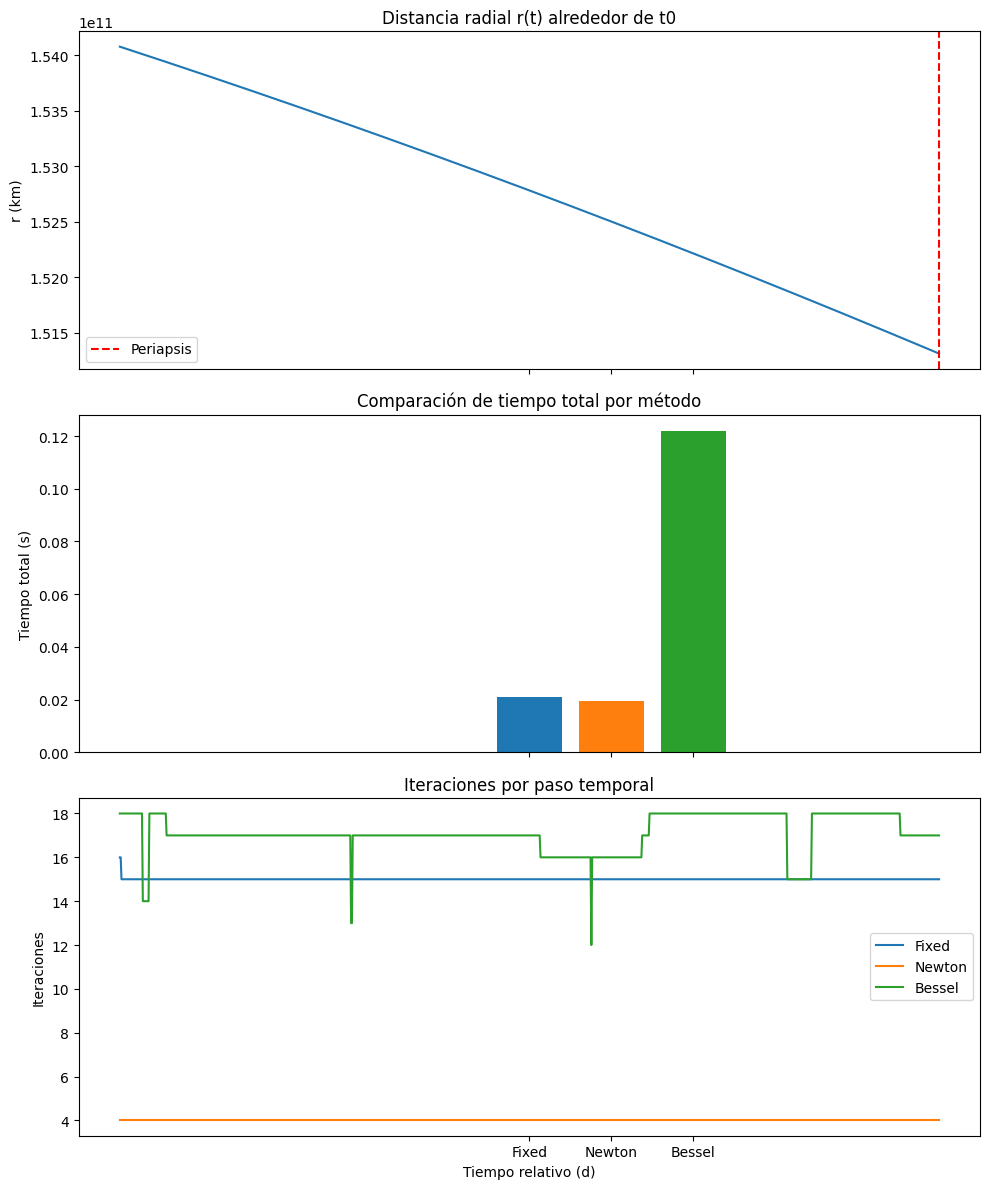

In [15]:
# 7) Visualizaciones
fig, ax = plt.subplots(3,1, figsize=(10,12), sharex=True)
ax[0].plot(ts_days, dfres['r_km'])
ax[0].set_ylabel('r (km)')
ax[0].set_title('Distancia radial r(t) alrededor de t0')
imin = dfres['r_km'].idxmin()
ax[0].axvline(ts_days[imin], color='red', linestyle='--', label='Periapsis')
ax[0].legend()
methods = ['Fixed','Newton','Bessel']
times = [dfres['time_fixed'].sum(), dfres['time_newton'].sum(), dfres['time_bessel'].sum()]
ax[1].bar(methods, times, color=['C0','C1','C2'])
ax[1].set_ylabel('Tiempo total (s)')
ax[1].set_title('Comparación de tiempo total por método')
ax[2].plot(ts_days, dfres['it_fixed'], label='Fixed')
ax[2].plot(ts_days, dfres['it_newton'], label='Newton')
ax[2].plot(ts_days, dfres['it_bessel'], label='Bessel')
ax[2].set_ylabel('Iteraciones')
ax[2].set_xlabel('Tiempo relativo (d)')
ax[2].set_title('Iteraciones por paso temporal')
ax[2].legend()
plt.tight_layout()
plt.show()